In [1]:
import numpy as np
import pandas as pd
from scipy.io import loadmat
import matplotlib.pyplot as plt
import pandas as pd
import time
import os
import sys
import zarr
import napari 
import dask.array as da
import math 

import dask.array as da 
from tifffile import imwrite


## Input variables

Refer to the  ISS- Correlate segmented endocytic spots to cell location (apical, basal, lateral) in 3D for more detailed infomation

In [2]:
# Change this variable to where your python packages are. Don't remove the r
package_dir = r'/Users/valerie/LLSM-CME-ANALYSIS/Final/src'

# Define the file directories (change these to reflect your directories)
base_dir =  r'/Volumes/ActiveNAS/Valerie/TransferFolder/'
input_file_directory = '20250717_MA3_Day3_5min_10um-05_analysis/'

# Change this variable to the center of the lumenoid is. Input of it is a list[0,1,2] -> [x,y,z]
lumen_center = [361,355,94]

# Change this variable to the apical point that is closer to the center. Input of it is a list[0,1,2] -> [x,y,z]
apical_start_point = [ 364 , 480 , 94 ]

# Change this variable to the apical point that is farther to the center. Input of it is a list[0,1,2] -> [x,y,z]
apical_end_point = [ 355 , 518 , 94 ]


# Change this variable to the basal point that is closer to the center. Input of it is a list[0,1,2] -> [x,y,z]
basal_start_point = [120,244,94]

# Change this variable to the basal point that is farther to the center. Input of it is a list[0,1,2] -> [x,y,z]
basal_end_point = [95,218,94]


## Napari visualization to set points

In [3]:
# Visualizing the detections in Napari
pythonPackagePath = os.path.abspath(package_dir)
sys.path.append(pythonPackagePath)
from intensity_time_plots import filter_track_ids_by_length_ranges, random_track_ids
from intensity_time_plots import intensity_time_plot, createBufferForLifetimeCohort
from intensity_time_plots import createBufferForLifetimeCohort_normalized, cumulative_plots, cumulative_plots_ax
# from parallel import Detector
from gaussian_visualization import visualize_3D_gaussians
zarr_file_directory = input_file_directory + 'zarr_file/all_channels_data'
zarr_full_path = os.path.join(base_dir, zarr_file_directory)

z2 = zarr.open(zarr_full_path, mode='r')

input_directory_tracks = 'datasets'
input_directory_filtered = 'filtered_tracks_final.pkl'
input_directory_all_tracks_full = os.path.join(base_dir, input_file_directory) + 'datasets/track_df_cleaned_final_full.pkl'
input_directory_point_detections = os.path.join(base_dir, input_file_directory) + 'detection/channel_1_detections.pkl'

input_directory_full_filtered_tracks = (os.path.join(base_dir, input_file_directory, 
                                                    input_directory_tracks, input_directory_filtered))
# Make a mask of the first time point of the detections
# spots_df = pd.read_pickle(r'/Volumes/ActiveNAS/Valerie/TransferFolder/20250717_MA3_Day3_5min_10um-05_analysis/detection/channel_1_detections.pkl')
spots_df = pd.read_pickle(input_directory_point_detections)
df_reset = spots_df.reset_index()

masks = visualize_3D_gaussians(zarr_obj = z2, gaussians_df = df_reset[df_reset['frame'] == 0])
# masks = visualize_3D_gaussians(zarr_obj = z2, gaussians_df = df)



# Create a napari viewer
viewer = napari.Viewer()

#open the zarr file in read mode
dask_array = da.from_zarr(z2)

count = 0
# Create points on napari and prints out the coordinates on mouse click
@viewer.mouse_drag_callbacks.append
def on_click(viewer, event):
    global count, lumen_center, apical_start_point, apical_end_point, basal_start_point, basal_end_point
    if event.type == 'mouse_press':  # Check specifically for a mouse press event
        # Get the world coordinates of the mouse cursor
        if count == 5:
            print("Resetting points.")
            count = 0
            for layer in list(viewer.layers):
                if layer._type_string == 'points': 
                    viewer.layers.remove(layer)
            lumen_center, apical_start_point, apical_end_point, basal_start_point, basal_end_point = [],[],[],[],[]
            print(lumen_center, apical_start_point, apical_end_point, basal_start_point, basal_end_point)
        world_coords = viewer.cursor.position
        if count == 0:
            print("Lumenoid center plotted at world coordinates", "[",round(world_coords[2]),",", round(world_coords[1]), ",", round(world_coords[0]), "]")
            lumen_center = [round(world_coords[2]), round(world_coords[1]), round(world_coords[0])]
        elif count == 1:
            print("Apical starting point plotted at world coordinates", "[",round(world_coords[2]),",", round(world_coords[1]), ",", round(world_coords[0]), "]")
            apical_start_point = [round(world_coords[2]), round(world_coords[1]), round(world_coords[0])]
        elif count == 2:
            print("Apical ending point plotted at world coordinates", "[",round(world_coords[2]),",", round(world_coords[1]), ",", round(world_coords[0]), "]")
            apical_end_point = [round(world_coords[2]), round(world_coords[1]), round(world_coords[0])]
        elif count == 3:
            print("Basal starting point plotted at world coordinates", "[",round(world_coords[2]),",", round(world_coords[1]), ",", round(world_coords[0]), "]")
            basal_start_point = [round(world_coords[2]), round(world_coords[1]), round(world_coords[0])]
        elif count == 4:
            print("Basal ending point plotted at world coordinates", "[",round(world_coords[2]),",", round(world_coords[1]), ",", round(world_coords[0]), "]")
            basal_end_point = [round(world_coords[2]), round(world_coords[1]), round(world_coords[0])] 
        count += 1            
        viewer.add_points(world_coords, size=10)

# first time point of the zarr file and the channel to detect
#the axis arrangement is (t,c,z,y,x)

# dask_array_slice = dask_array[48,channel_to_detect-1,:,:,:]
dask_array_slice = dask_array[0,2,:,:,:]

# Add the 3D stack to the viewer
layer_raw = viewer.add_image(dask_array_slice, name='fluorescence', interpolation3d = 'nearest', blending = 'additive', colormap = 'magenta')

# layer_mask = viewer.add_image(masks, name = 'detections mask')
layer_mask = viewer.add_image(masks, name = 'detections', interpolation3d = 'nearest', blending = 'additive', colormap = 'green')

#other useful parameters 
#color_map = list
#contrast_limits = list of list 

# Add Bounding Box
layer_raw.bounding_box.visible = True

Lumenoid center plotted at world coordinates [ 374 , 389 , 190 ]
Apical starting point plotted at world coordinates [ 340 , 388 , 190 ]
Apical ending point plotted at world coordinates [ 303 , 385 , 190 ]
Basal starting point plotted at world coordinates [ 227 , 384 , 190 ]
Basal ending point plotted at world coordinates [ 134 , 378 , 190 ]


## Preliminary code for setup

In [4]:


# Helper method to find radius from the center of a lumenoid and a point on the it
def find_radius(point):
    x1 = lumen_center[0]
    x2 = point[0]

    y1 = lumen_center[1]
    y2 = point[1]

    z1 = lumen_center[2]
    z2 = point[2]
    answer = math.sqrt((x2-x1) ** 2 + (y2-y1) ** 2 + (z2-z1) ** 2) 
    # answer = math.sqrt((x2-x1) ** 2 + (y2-y1) ** 2)
    return answer

apical_start_edge = find_radius(apical_start_point)
apical_end_edge = find_radius(apical_end_point)
basal_start_edge = find_radius(basal_start_point)
basal_end_edge = find_radius(basal_end_point)
print(apical_start_edge)

34.0147027033899


## Code to perform membrane region specification

In [5]:
track_df = pd.read_pickle(input_directory_all_tracks_full)
filtered_tracks = pd.read_pickle(input_directory_full_filtered_tracks)

membrane_regions = []
track_radius = []
for index, row in filtered_tracks.iterrows():
    test_point = [row[0].iloc[0], row[1].iloc[0], row[2].iloc[0]]
    #test_point = [row[0].iloc[0], row[1].iloc[0]]
    test_radius = find_radius(test_point)
        
    # Check if z_value falls within basal ranges
    if basal_start_edge <= test_radius < basal_end_edge:
        membrane_regions.append('Basal')

    # Check if z_value falls within apical ranges
    elif apical_start_edge <=  test_radius < apical_end_edge :
        membrane_regions.append('Apical')
        
    elif test_radius < apical_start_edge or test_radius > basal_end_edge:
        membrane_regions.append('N/A')
        print('Not in the lumenoid', index)
        print("Test radius: ", test_radius)
        print("Apical starting region: ", apical_start_edge)
        print("Basal ending region: ", basal_end_edge)
        print(row)
    else:
        membrane_regions.append('Lateral')
    track_radius.append(test_radius)

filtered_tracks['membrane_region'] = membrane_regions
filtered_tracks['track_radius'] = track_radius
print(apical_start_edge)
print(basal_start_edge)

Not in the lumenoid 7
Test radius:  277.04873217540626
Apical starting region:  34.0147027033899
Basal ending region:  240.25195108468944
mu_x                                113      308.0
472      308.0
942      308.0
1...
mu_y                                113      653.0
472      653.0
942      653.0
1...
mu_z                                113      138.0
472      139.0
942      139.0
1...
track_id                                                                            7
track_length                                                                       39
track_start                                                                         0
track_end                                                                          38
c3_peak                                                                     105.40625
c2_peak                                                                    155.446667
c1_peak                                                                     116.58125
c3

In [6]:
filtered_tracks.head()

,mu_x,mu_y,mu_z,track_id,track_length,track_start,track_end,c3_peak,c2_peak,c1_peak,...,C3_adjusted_voxel_sum_peak_frame,C2_adjusted_voxel_sum_peak_frame,C1_adjusted_voxel_sum_peak_frame,max_z_movement,max_y_movement,max_x_movement,channel2_positive,channel1_positive,membrane_region,track_radius
0,0 477.0 564 477.0 917 477.0 9...,0 506.0 564 506.0 917 506.0 9...,0 237.0 564 238.0 917 238.0 9...,0,83,0,82,153.702857,325.051429,443.394286,...,54,11,55,5.0,4.0,4.0,True,True,Basal,162.809705
1,263 376.0 327 375.0 690 376.0 1...,263 454.0 327 454.0 690 455.0 1...,263 180.0 327 182.0 690 181.0 1...,1,71,0,70,422.829412,949.229412,2876.951515,...,49,67,36,11.0,6.0,6.0,True,True,Apical,65.795137
2,271 263.0 299 264.0 813 264.0 1...,271 447.0 299 447.0 813 448.0 1...,271 149.0 299 150.0 813 150.0 1...,2,57,0,56,139.400000,231.228571,308.986207,...,50,46,51,12.0,5.0,8.0,True,True,Lateral,131.780120
3,259 333.0 477 333.0 939 333.0 1...,259 343.0 477 343.0 939 343.0 1...,259 164.0 477 165.0 939 166.0 1...,3,58,0,58,694.571429,1378.268571,5784.200000,...,14,38,19,9.0,2.0,4.0,True,True,Apical,66.880490
5,74 218.0 475 218.0 880 218.0 1...,74 338.0 475 339.0 880 339.0 1...,74 108.0 475 109.0 880 109.0 1...,5,39,0,38,197.371429,354.862857,747.531429,...,31,6,32,13.0,7.0,2.0,False,True,Basal,183.469343


In [7]:
filtered_tracks.columns

Index(['mu_x', 'mu_y', 'mu_z', 'track_id', 'track_length', 'track_start',
       'track_end', 'c3_peak', 'c2_peak', 'c1_peak', 'c3_peak_frame',
       'c2_peak_frame', 'c1_peak_frame', 'mean_displacement', 'mean_z',
       'mean_z_displacement', 'max_radius_from_origin',
       'max_distance_between_two_points', 'C3_adjusted_voxel_sum',
       'C2_adjusted_voxel_sum', 'C1_adjusted_voxel_sum',
       'C3_adjusted_voxel_sum_peak', 'C2_adjusted_voxel_sum_peak',
       'C1_adjusted_voxel_sum_peak', 'C3_adjusted_voxel_sum_peak_frame',
       'C2_adjusted_voxel_sum_peak_frame', 'C1_adjusted_voxel_sum_peak_frame',
       'max_z_movement', 'max_y_movement', 'max_x_movement',
       'channel2_positive', 'channel1_positive', 'membrane_region',
       'track_radius'],
      dtype='object')

# Print statements to see the number of endocytosis in each region

In [8]:

#  value = filtered_tracks.iloc[1,0]
# print(value)
#track_df.head()
#print(filtered_tracks.columns)
print("Basal endocytosis: ", len(filtered_tracks[filtered_tracks['membrane_region'] == "Basal"]))
print("Lateral endocytosis: ", len(filtered_tracks[filtered_tracks['membrane_region'] == "Lateral"]))
print("Apical endocytosis: ", len(filtered_tracks[filtered_tracks['membrane_region'] == "Apical"]))


Basal endocytosis:  245
Lateral endocytosis:  445
Apical endocytosis:  87


## Napari viewer to verify the membrane region specification

### Organize the track dataframe with number of unique frames for each track and maps it to a track id

In [12]:
from skimage import data
import random

# Report number of frames and a random color per track


# Calculate the number of unique frames for each track and create a mapping from track_id to number_of_frames
frame_counts = track_df.groupby('track_id')['frame'].nunique().to_dict()

# Map the frame counts to the original dataframe, creating a new column
track_df['number_of_frames'] = track_df['track_id'].map(frame_counts)

# Assuming 'track_df' is your DataFrame
track_ids = track_df['track_id'].unique().tolist()

# Generate a list of random colors
colors = [random.randint(0, 255) for _ in range(len(track_ids))]

# Create a dictionary that maps each track id to a random color
color_dict = dict(zip(track_ids, colors))

# Now you can use this dictionary to assign colors to the tracks
track_df['color'] = track_df['track_id'].map(color_dict)

# Sort track_df by frame and track_id
track_df = track_df.sort_values(by=['frame', 'track_id']).reset_index(drop=True)

track_df.head()


,frame,mu_x,mu_y,mu_z,amplitude,track_id,segment_id,sigma_z,sigma_y,sigma_x,...,c3_peak_max,c3_voxel_sum,c3_voxel_sum_adjusted,c3_peak_x,c3_peak_y,c3_peak_z,c3_vol_sig,c3_vol_bg,number_of_frames,color
0,0,477.0,506.0,237.0,399.0,0,NaN,3,2,2,...,188,22361,1520.750000,477,506,239,165,385,83,125
1,0,376.0,454.0,180.0,1262.0,1,NaN,3,2,2,...,486,62090,13063.611111,376,455,181,175,427,71,246
2,0,263.0,447.0,149.0,218.0,2,NaN,3,2,2,...,150,18400,1133.612565,263,447,149,145,336,57,222
3,0,333.0,343.0,164.0,2858.0,3,NaN,3,2,2,...,980,102339,9492.947368,335,341,167,175,441,58,142
4,0,290.0,365.0,147.0,520.0,4,NaN,3,2,2,...,257,30357,2569.500000,290,365,150,175,441,41,150


### Runs the napari viewer to see the membrane regions filtered tracks

In [13]:
# outputs the lumenoid
z2 = zarr.open(zarr_full_path, mode='r')
viewer = napari.Viewer()
dask_array = da.from_zarr(z2)
# first time point of the zarr file and the channel to detect
#the axis arrangement is (t,c,z,y,x)
dask_array_slice = dask_array[:,:,:,:,:]

layer_raw = viewer.add_image(dask_array_slice, channel_axis = 1, name = ['channel 1', 'channel 2', 'channel 3'])
track_properties = {'number_of_frames': track_df['number_of_frames'].to_numpy(), 'track_id_rand': track_df['color'].to_numpy()}


# Layer if you want too see ALL tracks and not just filtered tracks
#tracks_layer = viewer.add_tracks(track_df[["track_id", "frame", "c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'all tracks', properties=track_properties, color_by='track_id_rand', tail_length = 15, tail_width = 2, colormap = 'hsv')

# Basal tracks from filtered track datafram
basal_tracks_df = filtered_tracks[filtered_tracks['membrane_region'] == 'Basal']
basal_tracks_list = basal_tracks_df['track_id'].values
track_4 = track_df[track_df['track_id'].isin(basal_tracks_list)]
viewer.add_tracks(track_4[["track_id", "frame","c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'Basal tracks')

# Lateral tracks from filtered track datafram
lateral_tracks_df = filtered_tracks[filtered_tracks['membrane_region'] == 'Lateral']
lateral_tracks_list = lateral_tracks_df['track_id'].values
track_5 = track_df[track_df['track_id'].isin(lateral_tracks_list)]
viewer.add_tracks(track_5[["track_id", "frame", "c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'Lateral tracks')

# Apical tracks from filtered track datafram
apical_tracks_df = filtered_tracks[filtered_tracks['membrane_region'] == 'Apical']
apical_tracks_list = apical_tracks_df['track_id'].values
track_6 = track_df[track_df['track_id'].isin(apical_tracks_list)]
viewer.add_tracks(track_6[["track_id", "frame", "c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'Apical tracks')

# Add Bounding Box
layer_raw[0].bounding_box.visible = True
layer_raw[1].bounding_box.visible = True
layer_raw[2].bounding_box.visible = True

### Saves tracks to a pkl file

In [9]:
output_directory = 'datasets'
output_file_name = 'region_filtered_tracks_final.pkl' # can change this to filtered_tracks_final.pkl. region_filtered... just for testing purposes
output_directory_full = os.path.join(base_dir, input_file_directory, output_directory, output_file_name)
filtered_tracks.to_pickle(output_directory_full)


## Plotting graphs

In [15]:
path_to_detections = os.path.join(base_dir, input_file_directory) + 'detection/channel_1_detections.pkl'
df = pd.read_pickle(path_to_detections).reset_index()

In [16]:
track_df.head()

,frame,mu_x,mu_y,mu_z,amplitude,track_id,segment_id,sigma_z,sigma_y,sigma_x,...,c3_peak_max,c3_voxel_sum,c3_voxel_sum_adjusted,c3_peak_x,c3_peak_y,c3_peak_z,c3_vol_sig,c3_vol_bg,number_of_frames,color
0,0,206.0,233.0,103.0,368.0,0,NaN,3,2,2,...,368,14952,7698.658537,205,232,102,173,419,88,118
1,0,207.0,515.0,111.0,716.0,1,NaN,3,2,2,...,716,38187,20520.572052,205,514,110,172,401,67,176
2,0,199.0,501.0,101.0,355.0,2,NaN,3,2,2,...,355,17772,9653.492248,198,500,100,175,433,64,114
3,0,214.0,272.0,97.0,358.0,3,NaN,3,2,2,...,358,20765,10315.657895,214,271,96,175,441,53,223
4,0,227.0,234.0,102.0,596.0,4,NaN,3,2,2,...,596,33247,11890.675000,227,233,100,174,414,40,11


    frame  mu_x  mu_y  mu_z  amplitude  intensity  x_conf  y_conf  z_conf  \
19      0    53   530     4       1934       1934     0.5     0.5     0.5   
33      0   109   373     4        434        434     0.5     0.5     0.5   
34      0    38   458     5        552        552     0.5     0.5     0.5   
42      0    63   449     5         64         64     0.5     0.5     0.5   
47      0    91   433     5        618        618     0.5     0.5     0.5   

    amp_conf  int_conf  sigma_x  sigma_y  sigma_z            spot_id  
19       0.5       0.5        2        2        3   0_53.0_530.0_4.0  
33       0.5       0.5        2        2        3  0_109.0_373.0_4.0  
34       0.5       0.5        2        2        3   0_38.0_458.0_5.0  
42       0.5       0.5        2        2        3   0_63.0_449.0_5.0  
47       0.5       0.5        2        2        3   0_91.0_433.0_5.0  


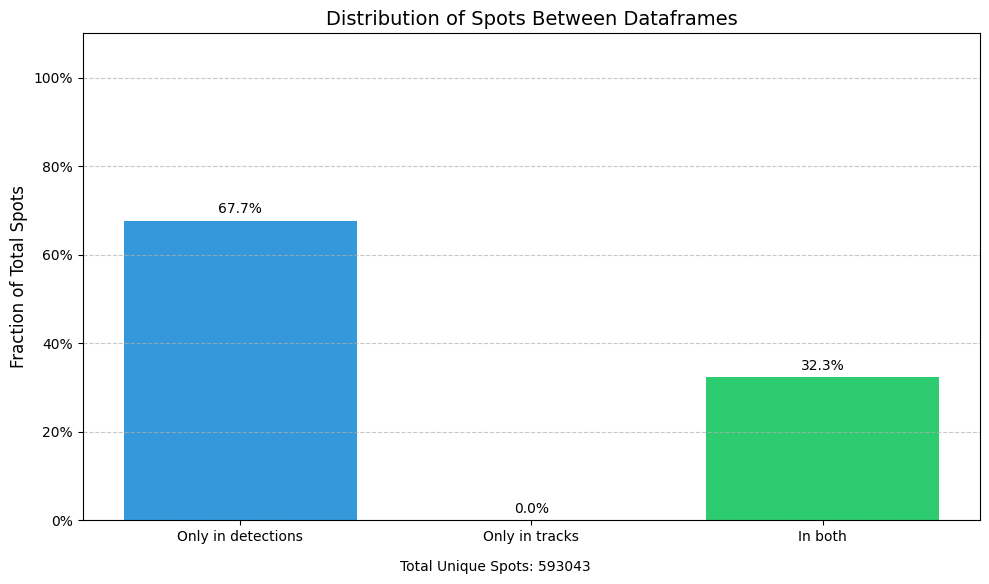

Spots only in df: 401288 (67.7%)
Spots only in track_df: 0 (0.0%)
Spots in both dataframes: 191755 (32.3%)
Total unique spots: 593043


In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Define a function to identify unique spots based on coordinates
def compare_dataframes(df1, df2, tolerance=0.5):
    # Create a unique identifier for each spot by combining frame and coordinates
    # Round coordinates to handle potential float/int differences
    df1 = df1.copy()
    df2 = df2.copy()
    df1['spot_id'] = df1.apply(lambda row: f"{int(row['frame'])}_{round(row['mu_x'], 1)}_{round(row['mu_y'], 1)}_{round(row['mu_z'], 1)}", axis=1)
    df2['spot_id'] = df2.apply(lambda row: f"{int(row['frame'])}_{round(row['mu_x'], 1)}_{round(row['mu_y'], 1)}_{round(row['mu_z'], 1)}", axis=1)
    # Find spots only in df1
    only_in_df1 = df1[~df1['spot_id'].isin(df2['spot_id'])]
    
    # Find spots only in df2
    only_in_df2 = df2[~df2['spot_id'].isin(df1['spot_id'])]
    # Find spots in both
    in_both = df1[df1['spot_id'].isin(df2['spot_id'])]

    # Find spots in both with respective regions
    lateral_track = df2[df2['membrane_region'] == 'Lateral']
    lateral_both = df1[df1['spot_id'].isin(lateral_track['spot_id'])]

    apical_track = df2[df2['membrane_region'] == 'Apical']
    apical_both = df1[df1['spot_id'].isin(apical_track['spot_id'])]

    basal_track = df2[df2['membrane_region'] == 'Basal']
    basal_both = df1[df1['spot_id'].isin(basal_track['spot_id'])]

    print(in_both.head())
    return {
        'only_in_df1': only_in_df1,
        'only_in_df2': only_in_df2,
        'in_both': in_both,
        'lateral_both' : lateral_both,
        'apical_both': apical_both,
        'basal_both': basal_both
    }

# # Compare dataframes
region_id_df = filtered_tracks[['track_id','membrane_region']]
merged_track_df = pd.merge(track_df, region_id_df, on='track_id', how='inner')
# lateral_track = df2[df2['membrane_region'] == 'Lateral']
# in_lateral_both = df1[df1['spot_id'].isin(lateral_track['spot_id'])]

result = compare_dataframes(df, merged_track_df)

# Calculate counts
only_in_df_count = len(result['only_in_df1'])
only_in_track_df_count = len(result['only_in_df2'])
in_both_count = len(result['in_both'])
total_spots = only_in_df_count + only_in_track_df_count + in_both_count

# Calculate fractions
fractions = {
    'Only in detections': only_in_df_count / total_spots,
    'Only in tracks': only_in_track_df_count / total_spots,
    'In both': in_both_count / total_spots
}

# Create a bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(fractions.keys(), fractions.values(), color=['#3498db', '#e74c3c', '#2ecc71'])

# Add percentage labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.1%}', ha='center', va='bottom')

# Add titles and labels
plt.title('Distribution of Spots Between Dataframes', fontsize=14)
plt.ylabel('Fraction of Total Spots', fontsize=12)
plt.ylim(0, 1.1)  # Set y-axis limit to leave room for percentage labels
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.grid(axis='y', linestyle='--', alpha=0.7)
 
# Add total count information
plt.figtext(0.5, 0.01, f'Total Unique Spots: {total_spots}', ha='center', fontsize=10)

# Improve appearance
plt.tight_layout(rect=[0, 0.03, 1, 0.97])  # Adjust layout to make room for the text at the bottom
plt.savefig('spot_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Print numeric results
print(f"Spots only in df: {only_in_df_count} ({fractions['Only in detections']:.1%})")
print(f"Spots only in track_df: {only_in_track_df_count} ({fractions['Only in tracks']:.1%})")
print(f"Spots in both dataframes: {in_both_count} ({fractions['In both']:.1%})")
print(f"Total unique spots: {total_spots}")

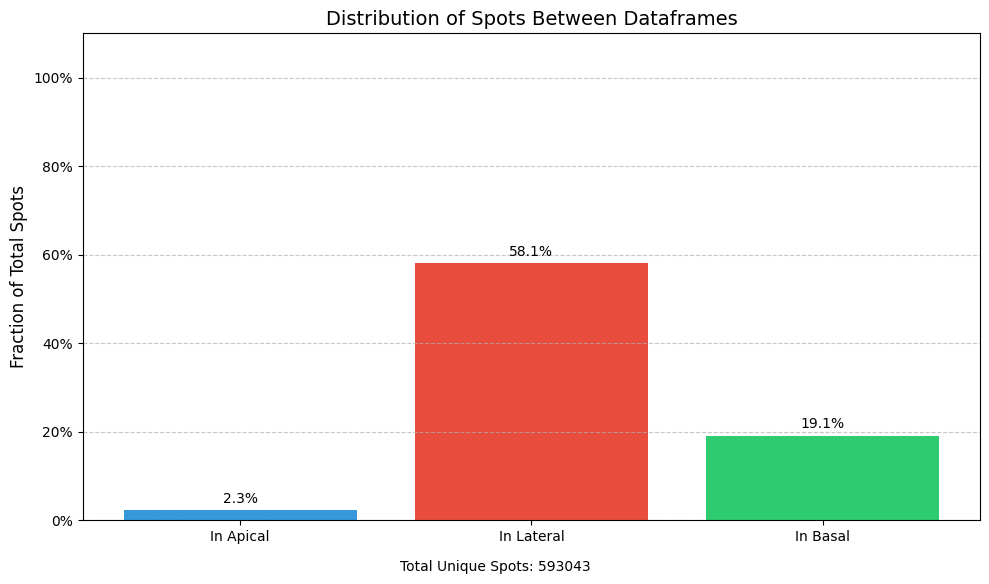

Spots in both dataframes and Apical: 4330 (2.3%)
Spots in both dataframes and Lateral: 111357 (58.1%)
Spots in both dataframes and Basal: 36626 (19.1%)
Total unique spots: 593043


In [76]:
# Calculate fractions
apical_both_count = len(result['apical_both'])
lateral_both_count = len(result['lateral_both'])
basal_both_count = len(result['basal_both'])
fractions = {
    'In Apical': apical_both_count / in_both_count,
    'In Lateral': lateral_both_count / in_both_count,
    'In Basal': basal_both_count / in_both_count
}

# Create a bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(fractions.keys(), fractions.values(), color=['#3498db', '#e74c3c', '#2ecc71'])

# Add percentage labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.1%}', ha='center', va='bottom')

# Add titles and labels
plt.title('Distribution of Spots Between Dataframes', fontsize=14)
plt.ylabel('Fraction of Total Spots', fontsize=12)
plt.ylim(0, 1.1)  # Set y-axis limit to leave room for percentage labels
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.grid(axis='y', linestyle='--', alpha=0.7)
 
# Add total count information
plt.figtext(0.5, 0.01, f'Total Unique Spots: {total_spots}', ha='center', fontsize=10)

# Improve appearance
plt.tight_layout(rect=[0, 0.03, 1, 0.97])  # Adjust layout to make room for the text at the bottom
plt.savefig('spot_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Print numeric results
print(f"Spots in both dataframes and Apical: {apical_both_count} ({fractions['In Apical']:.1%})")
print(f"Spots in both dataframes and Lateral: {lateral_both_count} ({fractions['In Lateral']:.1%})")
print(f"Spots in both dataframes and Basal: {basal_both_count} ({fractions['In Basal']:.1%})")
print(f"Total unique spots: {total_spots}")

## Intensity Plots

In [87]:
value_to_plot = 'voxel_sum_adjusted'
# value_to_plot = 'voxel_sum'
# value_to_plot = 'peak_mean'
# value_to_plot = 'peak_max'

if value_to_plot == 'voxel_sum_adjusted':
    background_channel_1 = 0
    background_channel_2 = 0
    background_channel_3 = 0

# use this list to see all possible values to plot
# track_df.columns

In [81]:
###### Set the following variables #######


# Background intensity for each channel

background_channel_1 = 240
background_channel_2 = 150
background_channel_3 = 170

# framerate (in milliseconds)

framerate_msec = 2500

# protein names (optional)

channel1_name = 'Arp2/3-Halo'
channel2_name = 'Dynamin2-tagGFP2'
channel3_name = 'AP2-tagRFPt'

In [77]:
# region_to_plot = 'Apical'
region_to_plot = 'Lateral'
# region_to_plot = 'Basal'
# region_to_plot = 'All'

if region_to_plot != 'All':
    filtered_tracks_all = filtered_tracks
    filtered_tracks = filtered_tracks_all[filtered_tracks_all['membrane_region'] == region_to_plot]

print('You are about to plot the following region: ', region_to_plot)

You are about to plot the following region:  Lateral


In [78]:
# range of track lengths to plot in each cohort, in frames
custom_length_ranges = [[5, 10], [11,15], [16, 20], [21, 25], [26, 30], [31, 40], [41,90]]

In [79]:
# by default you always plot channel 3 positive (fixing this)

# e.g. [True, True] to plot all three channels
# or [True, False] to plot channels 1 and 2

channels_to_plot = [True, True]

tracks_channel_subset = filtered_tracks[(filtered_tracks['channel1_positive'] == channels_to_plot[0]) &
                                 (filtered_tracks['channel2_positive'] == channels_to_plot[1])]

# will get this to work:

# e.g. [True, True, True] to plot all three channels
# or [True, False, True] to plot channels 1 and 3

# channels_to_plot = [True, True, True]

# tracks_channel_subset = filtered_tracks[(filtered_tracks['channel1_positive'] == channels_to_plot[0]) &
#                                  (filtered_tracks['channel2_positive'] == channels_to_plot[1]) &
#                                  (filtered_tracks['channel3_positive'] == channels_to_plot[2])]

# tracks_channel_subset.head()

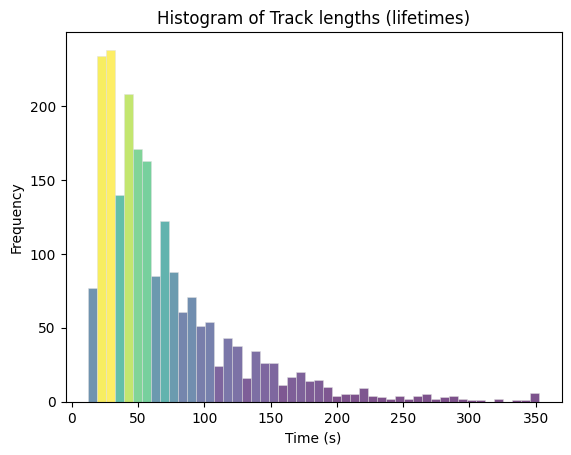

In [82]:
# Plot histogram of all track lengths (lifetimes)

# 'all lifetimes' is a variable of all the track lengths, multipilied by time per track

all_lifetimes =  tracks_channel_subset['track_length']*framerate_msec/1000

n, bins, patches = plt.hist(all_lifetimes, bins=50, facecolor='#2ab0ff', edgecolor='#e0e0e0', linewidth=0.5, alpha=0.7)

n = n.astype('int')

# Good old loop. Choose colormap of your taste
for i in range(len(patches)):
    patches[i].set_facecolor(plt.cm.viridis(n[i]/max(n)))

#plt.hist(all_lifetimes, bins=50, edgecolor=black)
plt.xlabel('Time (s)')  # X-axis label
plt.ylabel('Frequency')  # Y-axis label
plt.title('Histogram of Track lengths (lifetimes)')  # Title of the histogram
plt.show()

In [83]:
track_id_arrays = filter_track_ids_by_length_ranges(dataframe = tracks_channel_subset, track_length_buckets = custom_length_ranges, 
                                 track_id_col_name = 'track_id', track_length_col_name = 'track_length')

print(f'number of tracks between [5,10] frames long are {len(track_id_arrays[0])}')
print(f'number of tracks between [11,15] frames long are {len(track_id_arrays[1])}')
print(f'number of tracks between [16,20] frames long are {len(track_id_arrays[2])}')
print(f'number of tracks between [21,25] frames long are {len(track_id_arrays[3])}')
print(f'number of tracks between [26,30] frames long are {len(track_id_arrays[4])}')
print(f'number of tracks between [31,40] frames long are {len(track_id_arrays[5])}')
print(f'number of tracks between [41,90] frames long are {len(track_id_arrays[6])}')

number of tracks between [5,10] frames long are 311
number of tracks between [11,15] frames long are 378
number of tracks between [16,20] frames long are 331
number of tracks between [21,25] frames long are 253
number of tracks between [26,30] frames long are 194
number of tracks between [31,40] frames long are 242
number of tracks between [41,90] frames long are 374


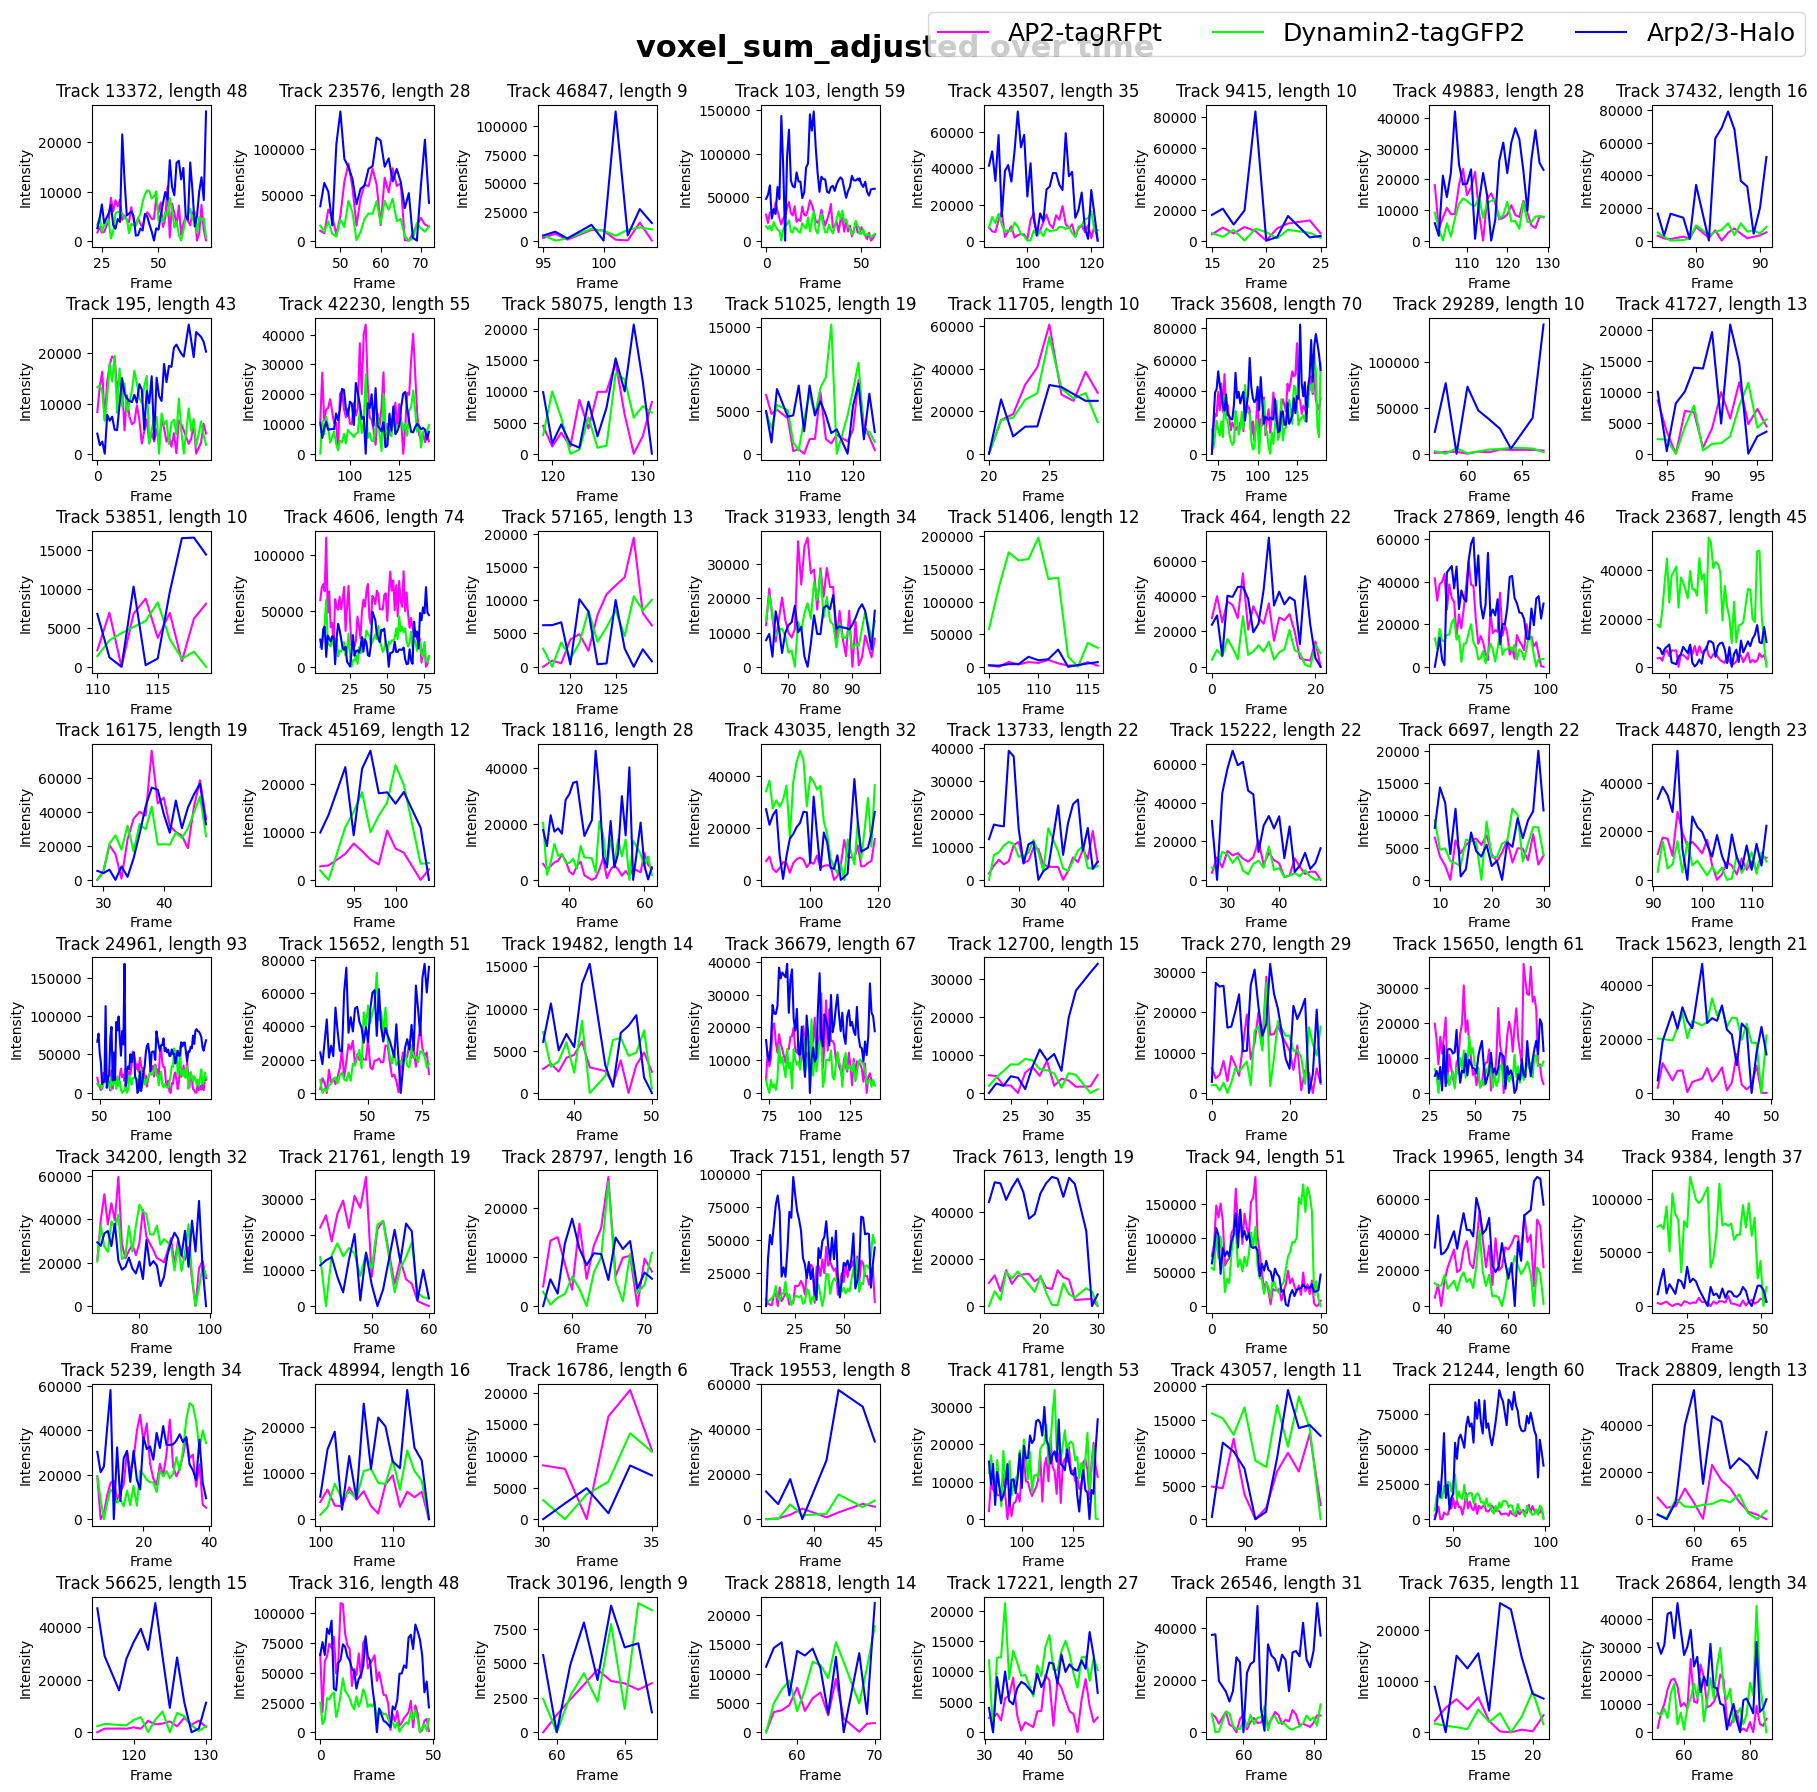

In [88]:

from intensity_time_plots import filter_track_ids_by_length_ranges, random_track_ids
from intensity_time_plots import intensity_time_plot, createBufferForLifetimeCohort
from intensity_time_plots import createBufferForLifetimeCohort_normalized, cumulative_plots, cumulative_plots_ax
# set 'normalized = False' to plot raw intensities

random_tracks = random_track_ids(dataframe = tracks_channel_subset, desired_length = [0, np.inf], 
                                 track_length_col_name = 'track_length', track_id_col_name = 'track_id', 
                                num_to_select = 64)

intensity_time_plot(dataframe = track_df, tracks_to_plot = random_tracks, 
intensity_to_plot = [f'c3_{value_to_plot}',f'c2_{value_to_plot}', f'c1_{value_to_plot}'], track_id_col_name = 'track_id', 
frame_col_name = 'frame', channels_to_plot = 3, legend_values = [channel3_name, channel2_name, channel1_name],
line_colors = ['magenta', 'lime', 'blue'], graph_title = f'{value_to_plot}', normalized=False)

## Condition Plots

In [17]:
from intensity_time_plots import filter_track_ids_by_length_ranges, random_track_ids
from intensity_time_plots import intensity_time_plot, createBufferForLifetimeCohort
from intensity_time_plots import createBufferForLifetimeCohort_normalized, cumulative_plots, cumulative_plots_ax

In [16]:
###### Set the following variables #######


# Background intensity for each channel

background_channel_1 = 240
background_channel_2 = 150
background_channel_3 = 170

# framerate (in milliseconds)

framerate_msec = 2500

# protein names (optional)

channel1_name = 'Arp2/3-Halo'
channel2_name = 'Dynamin2-tagGFP2'
channel3_name = 'AP2-tagRFPt'

In [15]:
value_to_plot = 'voxel_sum_adjusted'
# value_to_plot = 'voxel_sum'
# value_to_plot = 'peak_mean'
# value_to_plot = 'peak_max'

if value_to_plot == 'voxel_sum_adjusted':
    background_channel_1 = 0
    background_channel_2 = 0
    background_channel_3 = 0

# use this list to see all possible values to plot
# track_df.columns

In [ ]:
filtered_tracks_treatment = pd.read_pickle(r'\\10.158.28.194\ActiveNAS\Kenny\lumenoid_2_analysis\datasets\region_filtered_tracks_final.pkl')

In [9]:
# filtered_tracks_control
# label1 = 'Control'
# label2 = 'Tracks Filtered'

label1 = 'Apical'
label2 = 'Lateral'
label3 = 'Basal'

In [10]:
# region_to_plot = 'Apical'
# region_to_plot = 'Lateral'
# region_to_plot = 'Basal'
region_to_plot = 'All'

if region_to_plot == 'All':
    #filtered_tracks_all_control = filtered_tracks_control.copy()
    filtered_tracks_all_treatment = filtered_tracks_treatment.copy()

if region_to_plot != 'All':
   # filtered_tracks_all_control = filtered_tracks_control.copy()
    filtered_tracks_all_treatment = filtered_tracks_treatment.copy()
   # filtered_tracks_all_control = filtered_tracks_all_control[filtered_tracks_all_control['membrane_region'] == region_to_plot]
    filtered_tracks_all_treatment = filtered_tracks_all_treatment[filtered_tracks_all_treatment['membrane_region'] == region_to_plot]

print('You are about to plot the following region: ', region_to_plot)

You are about to plot the following region:  All


In [11]:
# range of track lengths to plot in each cohort, in frames
custom_length_ranges = [[5, 10], [11,15], [16, 20], [21, 25], [26, 30], [31, 40], [41,90]]

In [12]:
plot_all_channels = False
channels_to_plot = [True, True]
if plot_all_channels:
   # tracks_channel_subset_control = filtered_tracks_all_control.copy()
    tracks_channel_subset_treatment = filtered_tracks_all_treatment.copy()
else:
    channels_to_plot = channels_to_plot

   # tracks_channel_subset_control = filtered_tracks_all_control[(filtered_tracks_all_control['channel1_positive'] == channels_to_plot[0]) &
   #                                 (filtered_tracks_all_control['channel2_positive'] == channels_to_plot[1])]

    tracks_channel_subset_treatment = filtered_tracks_all_treatment[(filtered_tracks_all_treatment['channel1_positive'] == channels_to_plot[0]) &
                                        (filtered_tracks_all_treatment['channel2_positive'] == channels_to_plot[1])]
# else:
#     tracks_channel_subset_control = filtered_tracks_all_control[filtered_tracks_all_control['channel2_positive'] == True]
#     tracks_channel_subset_treatment = filtered_tracks_all_treatment[filtered_tracks_all_treatment['channel2_positive'] == True]

In [13]:
## seperating the regions into different variables

tracks_apical = tracks_channel_subset_treatment[tracks_channel_subset_treatment['membrane_region'] == 'Apical']
tracks_lateral = tracks_channel_subset_treatment[tracks_channel_subset_treatment['membrane_region'] == 'Lateral']
tracks_basal = tracks_channel_subset_treatment[tracks_channel_subset_treatment['membrane_region'] == 'Basal']

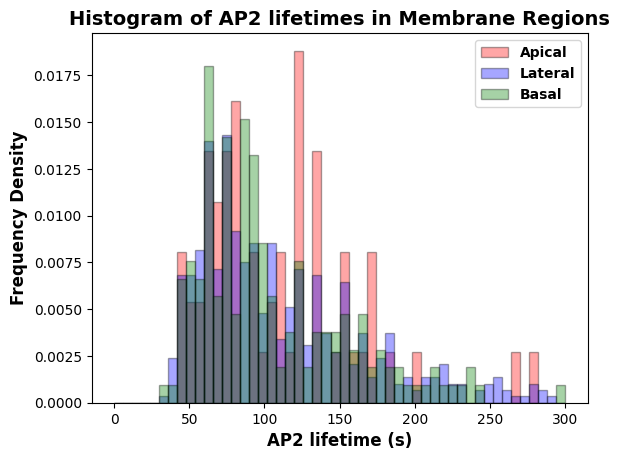

In [18]:
# Plot histogram of all track lengths (lifetimes)

# 'all lifetimes' is a variable of all the track lengths, multipilied by time per track
#all_lifetimes_control =  tracks_channel_subset_control['track_length']*framerate_msec/1000
#all_lifetimes_treatment =  tracks_channel_subset_treatment['track_length']*framerate_msec/1000
all_lifetimes_apical = tracks_apical['track_length']*framerate_msec/1000
all_lifetimes_lateral = tracks_lateral['track_length']*framerate_msec/1000
all_lifetimes_basal = tracks_basal['track_length']*framerate_msec/1000

# Plot histograms of membrane regions 
# on the same plot with 50 bins, and different colors
bins = np.linspace(0, 300, 51)  # Define the bin edges
plt.hist(all_lifetimes_apical, bins=bins, color = 'red', edgecolor='black', alpha=0.35, density=True, label=label1)
plt.hist(all_lifetimes_lateral, bins=bins, color = 'blue', edgecolor='black', alpha=0.35, density=True, label=label2)
plt.hist(all_lifetimes_basal, bins=bins, color = 'green', edgecolor='black', alpha=0.35, density=True, label=label3)
plt.xlabel('AP2 lifetime (s)', fontsize = 12, weight = 'bold')  # X-axis label
plt.ylabel('Frequency Density', fontsize = 12, weight = 'bold')  # Y-axis label
plt.title('Histogram of AP2 lifetimes in Membrane Regions', fontsize = 14, weight = 'bold')  # Title of the histogram


plt.legend(prop = {'weight':'bold'})
plt.show()

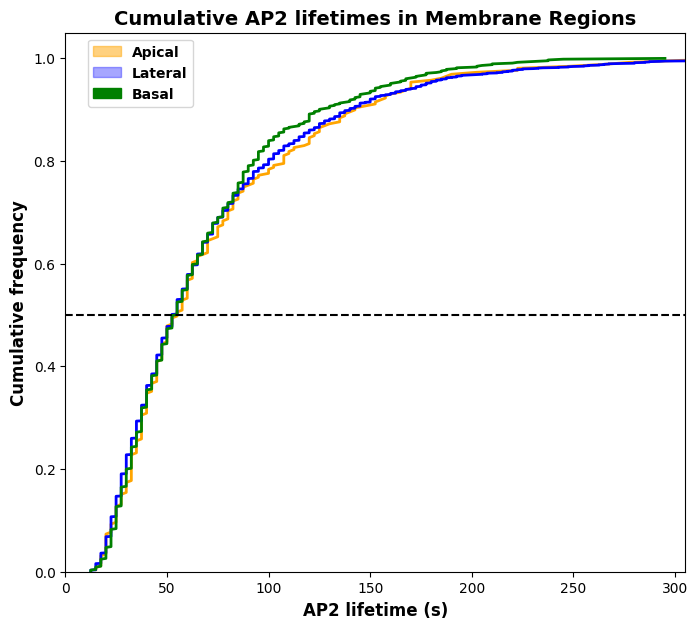

In [ ]:
# Cumulative plot of track lifetimes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_cumulative_lifetime(apical, lateral, basal, conditions_list, title = None):
    plt.figure(figsize=(8, 7))
    alpha_values = {'orange': 0.5, 'blue': 0.35}

    # Define colors for conditions
    conditions = {conditions_list[0]: (apical, 'orange'), conditions_list[1]: (lateral, 'blue'), conditions_list[2]: (basal,'green')}
    
    for label, (df, color) in conditions.items():
        subset = np.sort(df['track_length'])
        cum_freq = np.arange(1, len(subset) + 1) / len(subset)
        alpha = alpha_values.get(color, 1.0)
        plt.plot(subset, cum_freq, label=label, color=color, linewidth=2)

    # Formatting
    plt.xlabel('AP2 lifetime (s)', fontsize=12, weight='bold')
    plt.ylabel('Cumulative frequency', fontsize=12, weight='bold')
    plt.xlim(0, 305)
    plt.ylim(0, 1.05)

    # Add horizontal dashed reference line at 0.5
    plt.axhline(0.5, linestyle="--", color="black")
    
    # Add shaded region (0-50s)
    # plt.axvspan(0, 50, color='brown', alpha=0.2)

    # Title and legend
    plt.title(title, fontsize=14, weight='bold')

    legend_handles = []
    for label, (df, color) in conditions.items():
        alpha = alpha_values.get(color, 1.0)
        patch = mpatches.Patch(color=color,alpha = alpha, label=label)
        legend_handles.append(patch)
    plt.legend(handles = legend_handles, fontsize=12, loc='upper left', bbox_to_anchor=(0.025, 1), prop = {'weight':'bold'})
    plt.title('Cumulative AP2 lifetimes in Membrane Regions', fontsize = 14, weight = 'bold')  # Title of the histogram
    # Show plot
    # plt.show()
    return plt


all_lifetimes_apical_df = pd.DataFrame(all_lifetimes_apical)
all_lifetimes_lateral_df = pd.DataFrame(all_lifetimes_lateral)
all_lifetimes_basal_df = pd.DataFrame(all_lifetimes_basal)

# plt = plot_cumulative_lifetime(all_lifetimes_control_df, all_lifetimes_treatment_df, [label1, label2], title)
plt = plot_cumulative_lifetime(all_lifetimes_apical_df, all_lifetimes_lateral_df, all_lifetimes_basal_df, [label1, label2, label3])
# if plot_all_channels == True:
#     plt.text(0.5, 0.8, f'Plotting all channels: {plot_all_channels}', transform=plt.gca().transAxes, fontsize=12, weight='bold')
# if plot_all_channels == False:
#     plt.text(0.5, 0.8, f'Plotting channels: {channels_to_plot}', transform=plt.gca().transAxes, fontsize=12, weight='bold')
# plt.text(0.5, 0.75, f'Plotting region: {region_to_plot}', transform=plt.gca().transAxes, fontsize=12, weight='bold')

plt.show()

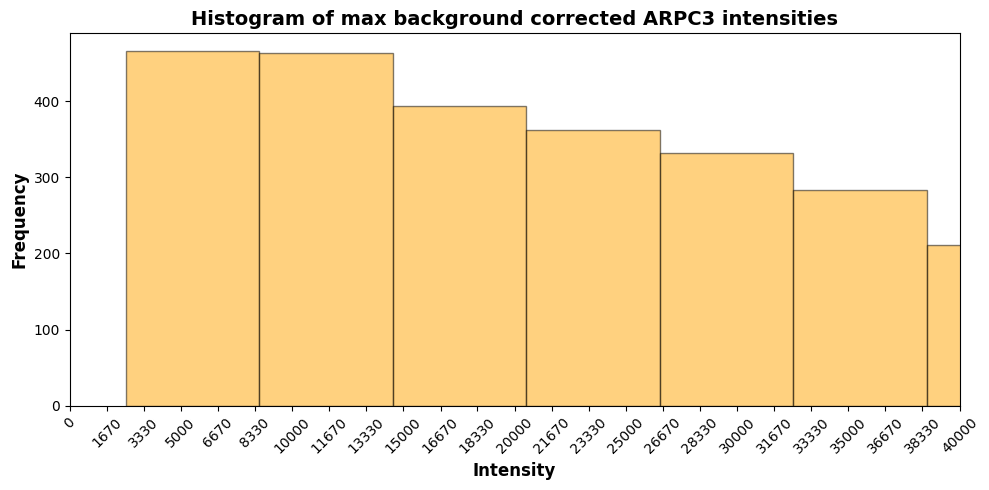

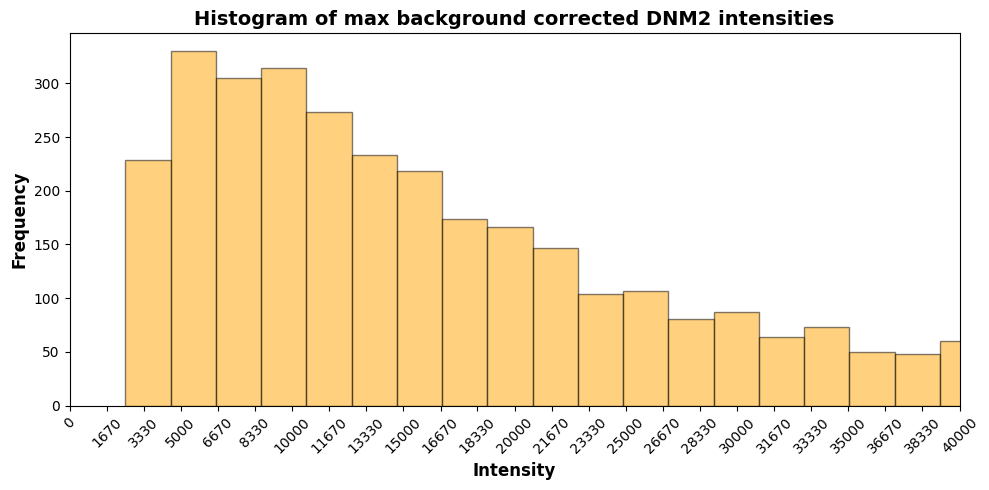

In [41]:
# Histogram of maximum background corrected ARPC3 intensity values, to determine cutoff for ARPC3-positive tracks
columns = ['C1_adjusted_voxel_sum_peak', 'C2_adjusted_voxel_sum_peak']
marker = ['ARPC3', 'DNM2']

# # Max AP2 intensity per track
# control_AP2 = tracks_channel_subset_control['C3_adjusted_voxel_sum'].reset_index(drop=True)

# max_control_AP2 = []
# for j in range(len(control_AP2)):
#     max_control_AP2.append(max(control_AP2[j]))  

for i in range(len(columns)):
    # Create a figure with 2 subplots side by side
    fig, ax1 = plt.subplots(1, 1, figsize=(10, 5))

    control =  tracks_channel_subset_treatment[columns[i]].reset_index(drop=True)
    

    max_control = []
    for j in range(len(control)):
        max_control.append(control[j])  # For every element in arpc3_control, get the max value



    # # Normalize to max AP2 intensity, optional
    # max_control = (np.array(max_control) / np.array(max_control_AP2)).tolist()
    


    # Generate 50 equally spaced bins between the min and max of max_arpc3_control and max_arpc3_OS
    # so I can plot the histograms of max_arpc3_control and max_arpc3_OS on the same plot
    # with the same binning
    bins = np.linspace(min(max_control), max(max_control), 200)


    # Plot histogram on the first subplot
    ax1.hist(max_control, bins=bins, color='orange', edgecolor='black', alpha=0.5, label=label1)

    # Calculate the data range
    # x_min = min(max_control)
    # x_max = max(max_control)
    x_min = 0
    x_max = 40000
    
    # Round minimum down and maximum up to nearest 10
    x_min_rounded = np.floor(x_min / 10) * 10
    x_max_rounded = np.ceil(x_max / 10) * 10
    
    # Create tick marks rounded to the nearest 10
    num_ticks =25  # Adjust this number for more or fewer ticks
    
    # Generate ticks rounded to the nearest 10
    x_ticks = np.linspace(x_min_rounded, x_max_rounded, num_ticks)
    x_ticks_rounded = np.round(x_ticks / 10) * 10  # Round to nearest 10
    
    ax1.set_xticks(x_ticks_rounded)
    ax1.set_xticklabels([f'{int(x)}' for x in x_ticks_rounded], rotation=45, fontsize=10)
    
    ax1.set_xlabel('Intensity', fontsize=12, weight='bold')
    ax1.set_ylabel('Frequency', fontsize=12, weight='bold')
    ax1.set_title('Histogram of max background corrected' + ' ' + marker[i] + ' ' +  'intensities', fontsize=14, weight='bold')

    # set x limit to 0 and 20000
    ax1.set_xlim(x_min_rounded, x_max_rounded)

    # Adjust layout
    plt.tight_layout()
    plt.show()

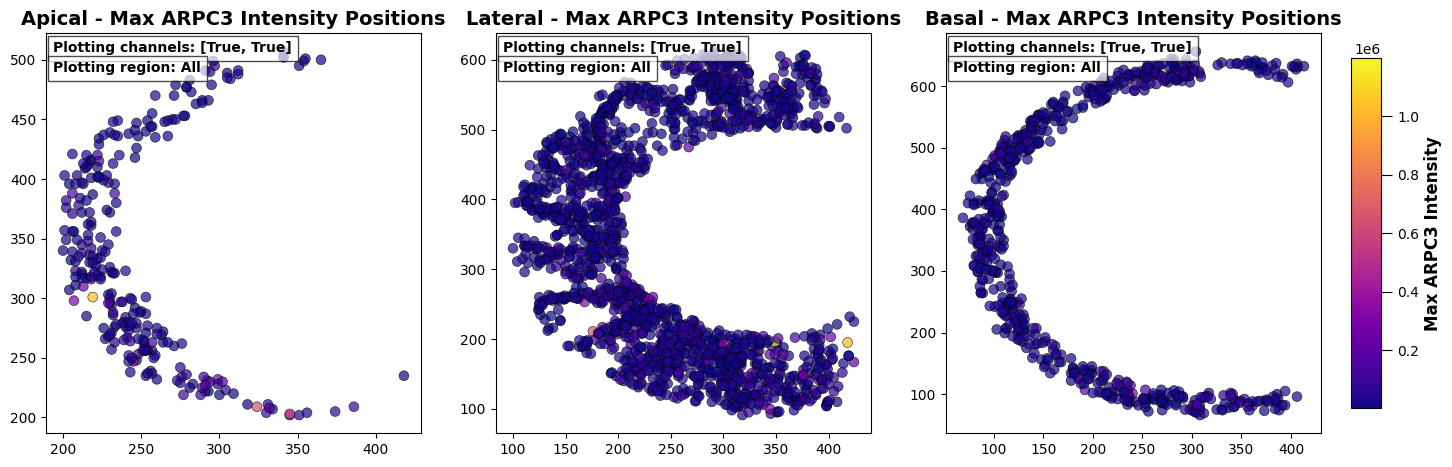

In [52]:
# For each track, looking at the position of the max intensity ARPC3 spot
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# Create a figure with 2 subplots side by side
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Extract the background corrected voxel sum for channel 1
#control = tracks_channel_subset_control['C1_adjusted_voxel_sum'].reset_index(drop=True)

apical_arpc = tracks_apical['C1_adjusted_voxel_sum'].reset_index(drop=True)
lateral_arpc = tracks_lateral['C1_adjusted_voxel_sum'].reset_index(drop=True)
basal_arpc = tracks_basal['C1_adjusted_voxel_sum'].reset_index(drop=True)

# Extract position coordinates
#control_x = tracks_channel_subset_control['mu_x'].reset_index(drop=True)
#control_y = tracks_channel_subset_control['mu_y'].reset_index(drop=True)
apical_x = tracks_apical['mu_x'].reset_index(drop=True)
apical_y = tracks_apical['mu_y'].reset_index(drop=True)

lateral_x = tracks_lateral['mu_x'].reset_index(drop=True)
lateral_y = tracks_lateral['mu_y'].reset_index(drop=True)

basal_x = tracks_basal['mu_x'].reset_index(drop=True)
basal_y = tracks_basal['mu_y'].reset_index(drop=True)

# Lists to store max intensity and corresponding coordinates
max_apical_intensity = []
max_apical_x = []
max_apical_y = []

max_lateral_intensity = []
max_lateral_x = []
max_lateral_y = []

max_basal_intensity = []
max_basal_x = []
max_basal_y = []

# Find max intensity and corresponding coordinates for apical
for j in range(len(apical_arpc)):
    max_val = max(apical_arpc[j])
    max_apical_intensity.append(max_val)
    
    # Find the index of the maximum intensity frame in this track
    max_idx = list(apical_arpc[j]).index(max_val)
    # print(j)
    # print(max_idx)
    
    # Get the x and y coordinates at that frame
    max_apical_x.append(apical_x[j].reset_index(drop = True)[max_idx])
    max_apical_y.append(apical_y[j].reset_index(drop = True)[max_idx])

# Find max intensity and corresponding coordinates for lateral
for j in range(len(lateral_arpc)):
    max_val = max(lateral_arpc[j])
    max_lateral_intensity.append(max_val)
    
    # Find the index of the maximum intensity frame in this track
    max_idx = list(lateral_arpc[j]).index(max_val)
    
    # Get the x and y coordinates at that frame
    max_lateral_x.append(lateral_x[j].reset_index(drop = True)[max_idx])
    max_lateral_y.append(lateral_y[j].reset_index(drop = True)[max_idx])

# Find max intensity and corresponding coordinates for basal
for j in range(len(basal_arpc)):
    max_val = max(basal_arpc[j])
    max_basal_intensity.append(max_val)
    
    # Find the index of the maximum intensity frame in this track
    max_idx = list(basal_arpc[j]).index(max_val)
    
    # Get the x and y coordinates at that frame
    max_basal_x.append(basal_x[j].reset_index(drop = True)[max_idx])
    max_basal_y.append(basal_y[j].reset_index(drop = True)[max_idx])

# Create color normalization for the intensity values
vmin = min(min(max_apical_intensity), min(max_lateral_intensity),min(max_basal_intensity))
vmax = max(max(max_apical_intensity), max(max_lateral_intensity),max(max_basal_intensity))
norm = Normalize(vmin=vmin, vmax=vmax)

# Apical scatter plot
scatter1 = ax1.scatter(max_apical_x, max_apical_y, c=max_apical_intensity, 
                       cmap='plasma', alpha=0.7, s=50, edgecolors='black', linewidths=0.5, norm=norm)

# Lateral scatter plot
scatter2 = ax2.scatter(max_lateral_x, max_lateral_y, c=max_lateral_intensity, 
                       cmap='plasma', alpha=0.7, s=50, edgecolors='black', linewidths=0.5, norm=norm)

# Basal scatter plot
scatter3 = ax3.scatter(max_basal_x, max_basal_y, c=max_basal_intensity, 
                       cmap='plasma', alpha=0.7, s=50, edgecolors='black', linewidths=0.5, norm=norm)

# Add color bar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(ScalarMappable(norm=norm, cmap='plasma'), cax=cbar_ax)
cbar.ax.set_ylabel('Max ARPC3 Intensity', fontsize=12, weight='bold')
cbar.ax.tick_params(size=8, labelsize=10)

# Set titles and labels
ax1.set_title( label1 + ' ' + '- Max ARPC3 Intensity Positions', fontsize=14, weight='bold')
ax2.set_title( label2 + ' ' + '- Max ARPC3 Intensity Positions', fontsize=14, weight='bold')
ax3.set_title( label3 + ' ' + '- Max ARPC3 Intensity Positions', fontsize=14, weight='bold')
for ax in [ax1, ax2, ax3]:
    # Move text to top-left corner with better spacing and transparency
    if 'plot_all_channels' in globals():
        if plot_all_channels == True:
            ax.text(0.02, 0.98, f'Plotting channels: {plot_all_channels}', 
                   transform=ax.transAxes, fontsize=10, weight='bold',
                   bbox=dict(facecolor='white', alpha=0.7), verticalalignment='top')
        else:
            ax.text(0.02, 0.98, f'Plotting channels: {channels_to_plot}', 
                   transform=ax.transAxes, fontsize=10, weight='bold',
                   bbox=dict(facecolor='white', alpha=0.7), verticalalignment='top')
    
    if 'region_to_plot' in globals():
        ax.text(0.02, 0.93, f'Plotting region: {region_to_plot}', 
               transform=ax.transAxes, fontsize=10, weight='bold',
               bbox=dict(facecolor='white', alpha=0.7), verticalalignment='top')

# Adjust layout
plt.subplots_adjust(left=0.05, right=0.9, bottom=0.1, top=0.9, wspace=0.2)
plt.show()

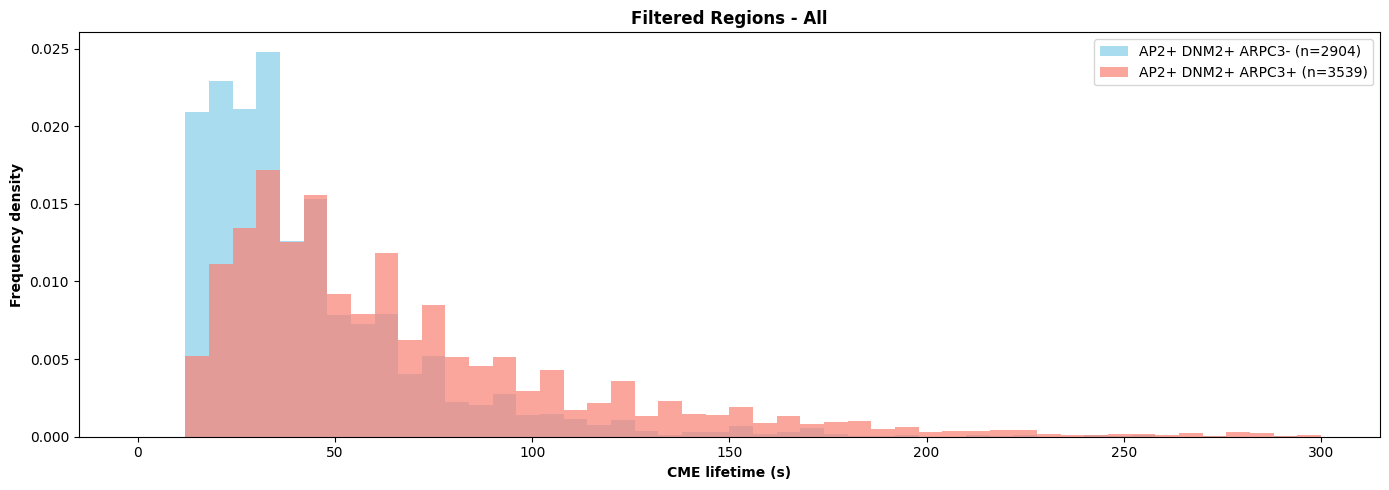

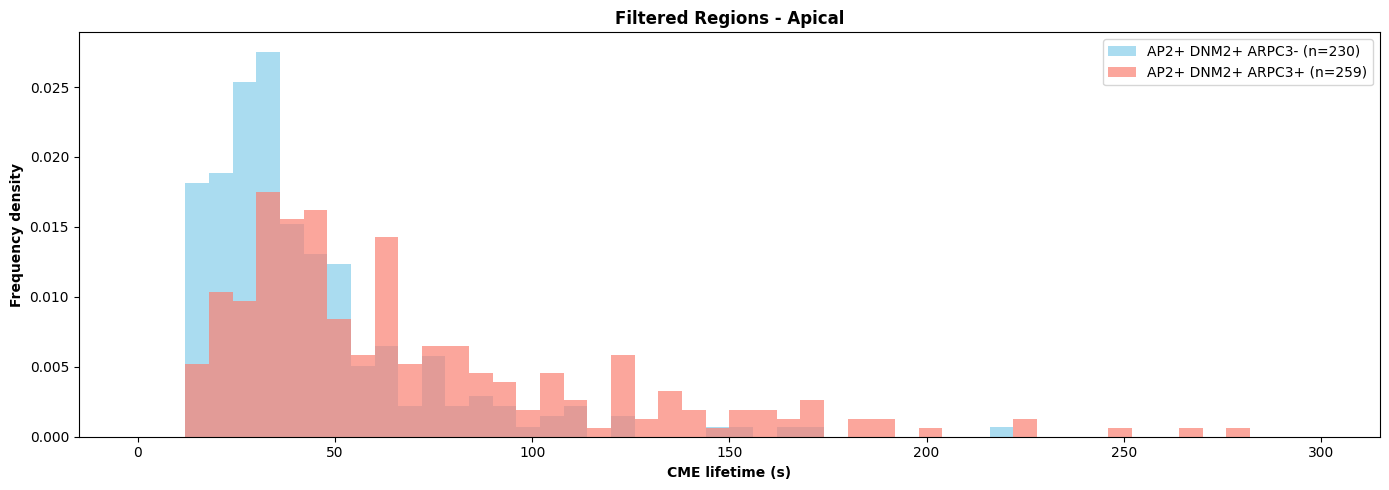

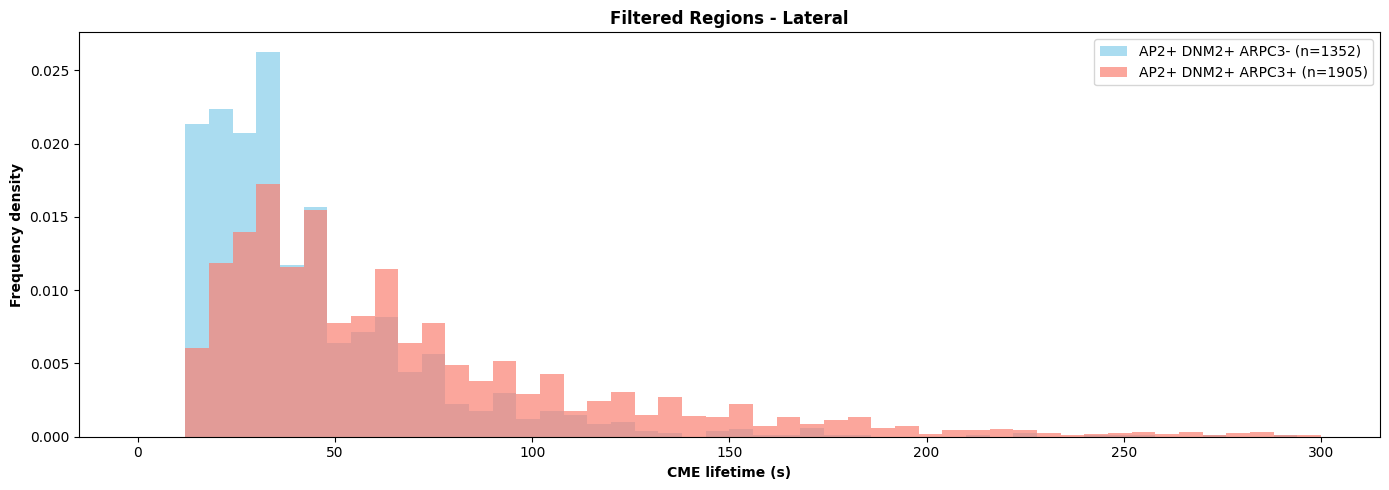

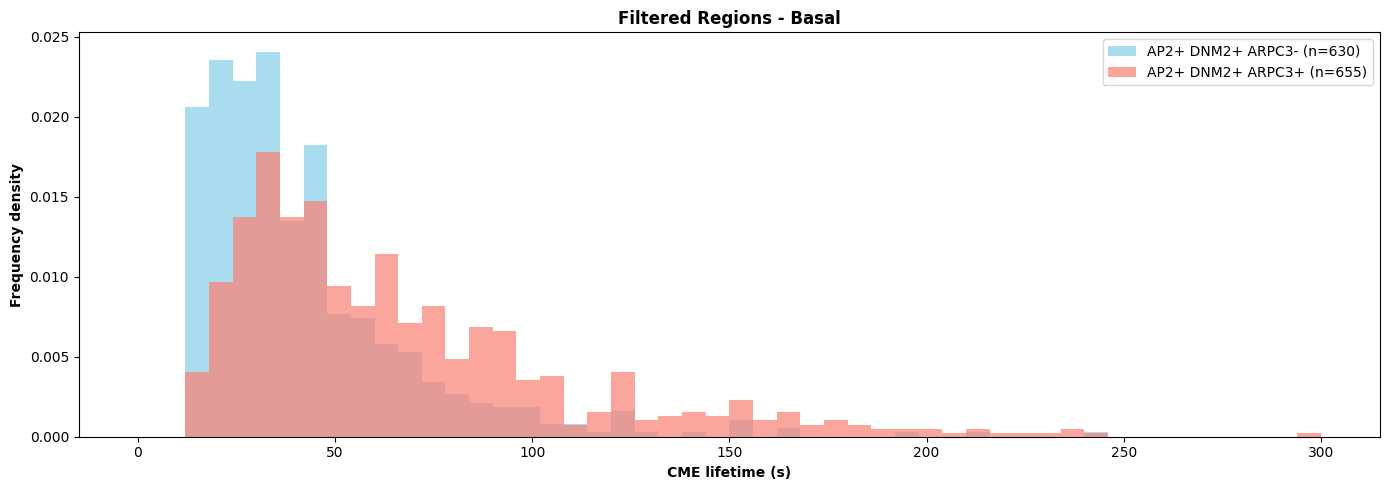

,Region,Condition,AP2+ DNM2+ ARPC3+ Count,AP2+ DNM2+ ARPC3- Count,AP2+ DNM2+ ARPC3+ Mean Lifetime (s),AP2+ DNM2+ ARPC3- Mean Lifetime (s)
0,All,Filtered Regions,3539,2904,68.214185,43.495179
1,Apical,Filtered Regions,259,230,71.843629,43.369565
2,Lateral,Filtered Regions,1905,1352,69.750656,43.859098
3,Basal,Filtered Regions,655,630,66.412214,41.650794


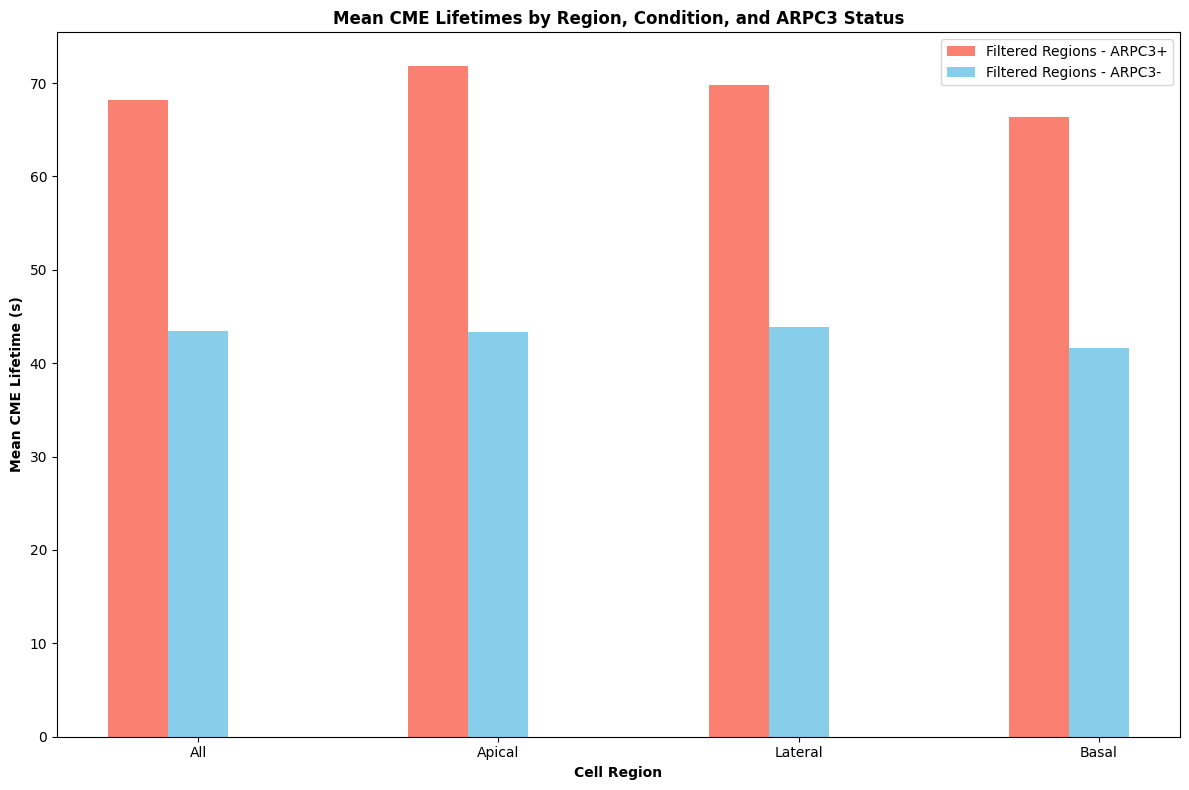

In [ ]:
# # Set style parameters for better-looking plots
# plt.rcParams.update({'font.size': 12})
# sns.set_style("whitegrid")

# Function to plot the lifetime histograms for specified conditions
def plot_lifetime_by_region(track_data, label1, region_name="All", normalize=True):
    """
    Plot lifetime histograms for tracks with AP2+ DNM2+ ARPC3- vs AP2+ DNM2+ ARPC3+
    
    Parameters:
    -----------
    data : DataFrame
        The track data
    region_name : str
        The cell region to filter for (or "All")
    normalize : bool
        Whether to normalize the histograms (density=True)
    """
    fig, axes = plt.subplots(1, 1, figsize=(14, 5))
    
    # Filter for region if specified
    if region_name != "All":
        track_data_subset = track_data[track_data['membrane_region'] == region_name].copy()
    else:
        track_data_subset = track_data.copy()
    
    # Convert track length to seconds
    track_data_subset['lifetime'] = track_data_subset['track_length'] * framerate_msec / 1000
    
    # Define bins for consistency across plots
    bins = np.linspace(0, 300, 51)  # 0 to 160 seconds, 40 bins
    
    # Filter for AP2+ DNM2+ ARPC3+ and AP2+ DNM2+ ARPC3-

    df = track_data_subset
    title = f"{label1} - {region_name}"
    arpc3_pos = df[(df['channel1_positive'] == True) & (df['channel2_positive'] == True)]
    arpc3_neg = df[(df['channel1_positive'] == False) & (df['channel2_positive'] == True)]
        
    # Plot the histograms
    axes.hist(arpc3_neg['lifetime'], bins=bins, alpha=0.7, density=normalize,
                color='skyblue', label='AP2+ DNM2+ ARPC3-')
    axes.hist(arpc3_pos['lifetime'], bins=bins, alpha=0.7, density=normalize,
                color='salmon', label='AP2+ DNM2+ ARPC3+')
        
    # Add labels and legend
    axes.set_xlabel('CME lifetime (s)', fontweight='bold')
    if normalize:
        axes.set_ylabel('Frequency density', fontweight='bold')
    else:
        axes.set_ylabel('Count', fontweight='bold')
    axes.set_title(title, fontweight='bold')
    axes.legend()
        
    # Add track counts to the legend
    handles, labels = axes.get_legend_handles_labels()
    labels[0] += f" (n={len(arpc3_neg)})"
    labels[1] += f" (n={len(arpc3_pos)})"
    axes.legend(handles, labels)
    plt.tight_layout()
    return fig

# Create plots for each region
regions = ["All", "Apical", "Lateral", "Basal"]

# For each region, create and display the plot
fig_label = "Filtered Regions"
for region in regions:
    fig = plot_lifetime_by_region(filtered_tracks_treatment, fig_label, region_name=region)
    plt.show()


# Calculate statistics for a summary table
def calculate_region_stats(track_data, label1):
    """Calculate summary statistics for each region and condition"""
    regions = ["All", "Apical", "Lateral", "Basal"]
    stats = []
    
    for region in regions:
        for df_name, df in [(label1, track_data)]:
            if region != "All":
                subset = df[df['membrane_region'] == region].copy()
            else:
                subset = df.copy()
                
            # Count AP2+ DNM2+ ARPC3+ and AP2+ DNM2+ ARPC3- tracks
            ap2_dnm2_arpc3_pos = subset[(subset['channel1_positive'] == True) & 
                                         (subset['channel2_positive'] == True)].copy()
            ap2_dnm2_arpc3_neg = subset[(subset['channel1_positive'] == False) & 
                                         (subset['channel2_positive'] == True)].copy()
            
            # Calculate mean lifetimes
            ap2_dnm2_arpc3_pos['lifetime'] = ap2_dnm2_arpc3_pos['track_length'] * framerate_msec / 1000
            ap2_dnm2_arpc3_neg['lifetime'] = ap2_dnm2_arpc3_neg['track_length'] * framerate_msec / 1000
            
            mean_pos = ap2_dnm2_arpc3_pos['lifetime'].mean() if len(ap2_dnm2_arpc3_pos) > 0 else 0
            mean_neg = ap2_dnm2_arpc3_neg['lifetime'].mean() if len(ap2_dnm2_arpc3_neg) > 0 else 0
            
            stats.append({
                "Region": region,
                "Condition": df_name,
                "AP2+ DNM2+ ARPC3+ Count": len(ap2_dnm2_arpc3_pos),
                "AP2+ DNM2+ ARPC3- Count": len(ap2_dnm2_arpc3_neg),
                "AP2+ DNM2+ ARPC3+ Mean Lifetime (s)": mean_pos,
                "AP2+ DNM2+ ARPC3- Mean Lifetime (s)": mean_neg
            })
    
    return pd.DataFrame(stats)

# Display summary statistics
stats_df = calculate_region_stats(filtered_tracks_treatment, fig_label)
display(stats_df)

# Create a more visual plot of the mean lifetimes
plt.figure(figsize=(12, 8))

# Group by region and condition
grouped = stats_df.groupby(['Region', 'Condition'])

# For each region, plot the mean lifetimes for each condition and ARPC3 status
regions = ["All", "Apical", "Lateral", "Basal"]
pos = np.arange(len(regions))
width = 0.2  # Width of the bars

for i, cond in enumerate([fig_label]):
    pos_means = [grouped.get_group((region, cond))["AP2+ DNM2+ ARPC3+ Mean Lifetime (s)"].values[0] 
                for region in regions]
    neg_means = [grouped.get_group((region, cond))["AP2+ DNM2+ ARPC3- Mean Lifetime (s)"].values[0] 
                for region in regions]
    
    plt.bar(pos + i*width - width/2, pos_means, width, 
            label=f"{cond} - ARPC3+", color='salmon' if i==0 else 'lightcoral')
    plt.bar(pos + i*width + width/2, neg_means, width, 
            label=f"{cond} - ARPC3-", color='skyblue' if i==0 else 'lightsteelblue')

plt.xlabel('Cell Region', fontweight='bold')
plt.ylabel('Mean CME Lifetime (s)', fontweight='bold')
plt.title('Mean CME Lifetimes by Region, Condition, and ARPC3 Status', fontweight='bold')
plt.xticks(pos + width/2, regions)
plt.legend()
plt.tight_layout()
plt.show()

Plotting region: All
Filtered tracks: 10044
Plotting region: Apical
Filtered tracks: 880
Plotting region: Lateral
Filtered tracks: 4883
Plotting region: Basal
Filtered tracks: 2011


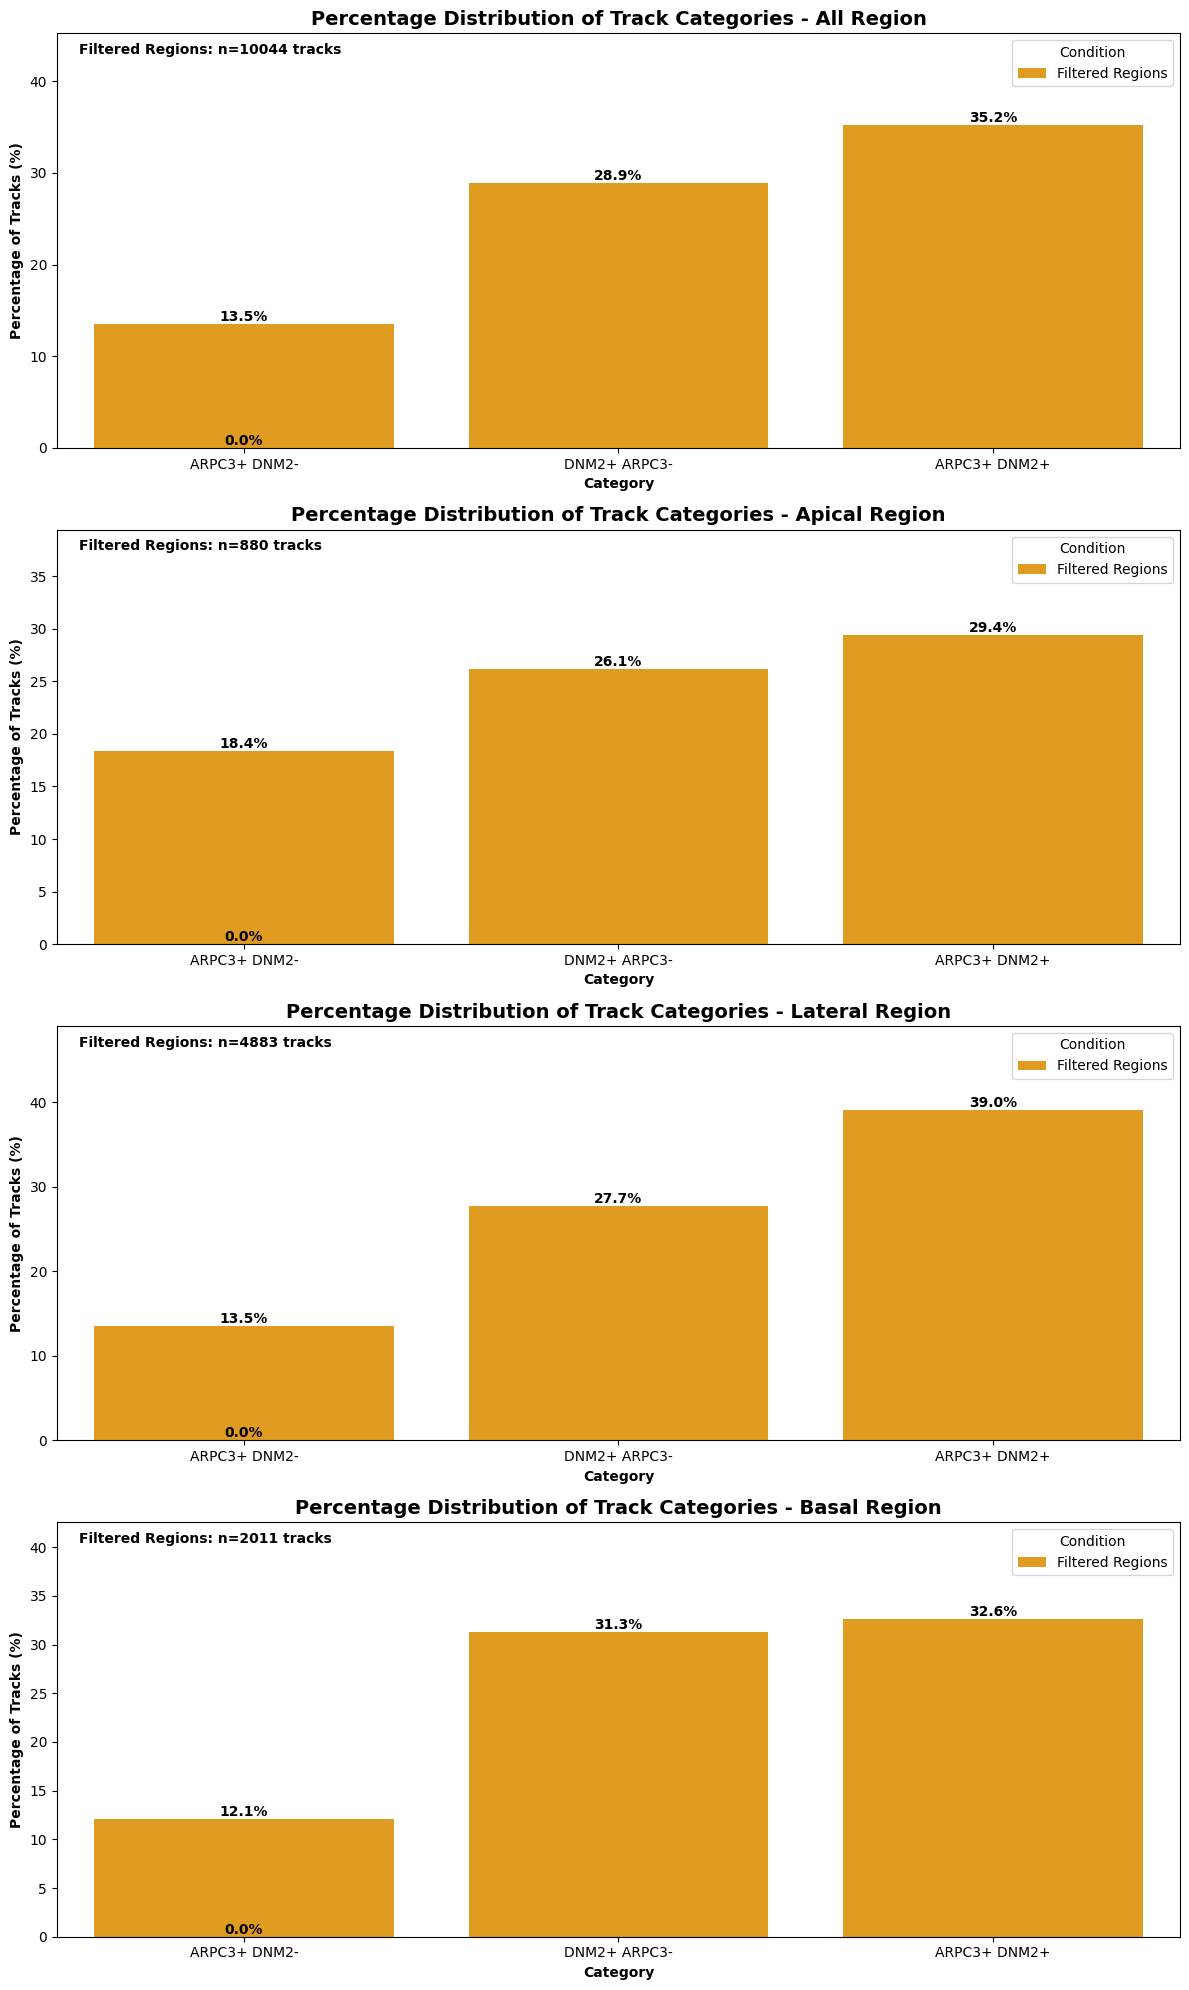

In [68]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

def plot_percentages_by_region(filtered_tracks_data, label1):
    """
    Plot percentages of track categories across different regions for control and OS conditions.
    
    Parameters:
    -----------
    filtered_tracks_control : DataFrame
        filtered tracks Data
    """
    # Define regions to plot
    regions = ["All", "Apical", "Lateral", "Basal"]
    
    # Function to calculate percentages
    def calculate_percentages(df):
        total_tracks = df['track_id'].nunique()
            
        c1_plus_c2_minus = df[(df['channel1_positive']) & (~df['channel2_positive'])]['track_id'].nunique() / total_tracks * 100
        c2_plus_c1_minus = df[(df['channel2_positive']) & (~df['channel1_positive'])]['track_id'].nunique() / total_tracks * 100
        double_positive = df[(df['channel1_positive']) & (df['channel2_positive'])]['track_id'].nunique() / total_tracks * 100
        
        return {'ARPC3+ DNM2-': c1_plus_c2_minus, 'DNM2+ ARPC3-': c2_plus_c1_minus, 'ARPC3+ DNM2+': double_positive}
    
    # Create a figure with subplots - one row for each region
    fig, axes = plt.subplots(len(regions), 1, figsize=(12, 5 * len(regions)))
    
    # Process each region
    for i, region in enumerate(regions):
        # Filter data for the current region
        if region == 'All':
            #filtered_region_control = filtered_tracks_control.copy()
            filtered_region_tracks = filtered_tracks_data.copy()
        else:
            #filtered_region_control = filtered_tracks_control[filtered_tracks_control['membrane_region'] == region].copy()
            filtered_region_tracks = filtered_tracks_data[filtered_tracks_data['membrane_region'] == region].copy()
        
        # Print info about the region being plotted
        print(f'Plotting region: {region}')
        print(f'Filtered tracks: {filtered_region_tracks["track_id"].nunique()}')
        
        
        # Compute percentages for each condition
        track_percentages = calculate_percentages(filtered_region_tracks)
        #os_percentages = calculate_percentages(filtered_region_OS)
        
        # Convert to DataFrame for plotting
        data = []
        for condition, percentages in zip([label1], [track_percentages]):
            for category, value in percentages.items():
                data.append({'Condition': condition, 'Category': category, 'Percentage': value})
        
        df_plot = pd.DataFrame(data)
        
        # Get current axis
        ax = axes[i] if len(regions) > 1 else axes
        
        # Plot using seaborn barplot
        sns.barplot(x='Category', y='Percentage', hue='Condition', data=df_plot, 
                   palette={label1: 'orange', label2: 'blue'}, 
                   capsize=0.1, ax=ax)
        
        # Add track counts as text annotations
        for j, condition in enumerate([label1]):
            track_count = filtered_region_tracks["track_id"].nunique()
            ax.text(0.02, 0.95 - j*0.05, f'{condition}: n={track_count} tracks', 
                   transform=ax.transAxes, fontsize=10, fontweight='bold')
        
        # Customize plot
        ax.set_xlabel("Category", fontweight='bold')
        ax.set_ylabel("Percentage of Tracks (%)", fontweight='bold')
        ax.set_title(f"Percentage Distribution of Track Categories - {region} Region", fontsize=14, fontweight='bold')
        ax.legend(title="Condition", loc='upper right')
        ax.set_ylim(0, min(100, df_plot['Percentage'].max() + 10))  # Adjust y-axis for better visualization
        
        # Add percentage values on top of bars
        for p in ax.patches:
            ax.annotate(f'{p.get_height():.1f}%', 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha = 'center', va = 'bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    return fig

# Create and display the plots
fig = plot_percentages_by_region(filtered_tracks_treatment, fig_label)
plt.show()